In [1]:
import os
import math
import warnings
import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from datetime import datetime, timedelta

In [2]:
!pip install holidays

# **Load Dataset**

In [2]:
df = pd.read_csv('hybrid_traffic_7d.csv')
df.head()

,timestamp_wib,tick,intersectionId,approach,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,weather_condition,weather_temp_c,accident_count,roadwork_flag,event_flag,target_volume_15m,target_volume_2h,target_volume_4h
0,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,N,10,598.77,55.15,0,0.0,34,0.00,Cloudy,29.7,0,0,0,453.48,781.37,398.87
1,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,E,0,0.00,57.74,0,0.0,20,0.00,Cloudy,29.7,0,0,0,395.93,397.61,640.25
2,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,S,11,638.17,52.43,0,0.0,37,0.06,Cloudy,29.7,0,0,0,548.08,358.41,164.98
3,2026-05-01T00:00:00+07:00,0,JKT-TMG-SIM-01,W,6,333.01,52.50,0,0.0,20,0.00,Cloudy,29.7,0,0,0,351.34,302.14,305.34
4,2026-05-01T00:01:00+07:00,1,JKT-TMG-SIM-01,N,9,563.60,54.09,0,0.0,33,0.03,Cloudy,29.8,0,0,0,495.46,701.63,590.70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40320 entries, 0 to 40319
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_wib        40320 non-null  object 
 1   tick                 40320 non-null  int64  
 2   intersectionId       40320 non-null  object 
 3   approach             40320 non-null  object 
 4   vehicle_count_1min   40320 non-null  int64  
 5   volume_veh_per_hour  40320 non-null  float64
 6   avg_speed_kmh        40320 non-null  float64
 7   queue_length_veh     40320 non-null  int64  
 8   wait_time_min        40320 non-null  float64
 9   green_seconds        40320 non-null  int64  
 10  density_percent      40320 non-null  float64
 11  weather_condition    40320 non-null  object 
 12  weather_temp_c       40320 non-null  float64
 13  accident_count       40320 non-null  int64  
 14  roadwork_flag        40320 non-null  int64  
 15  event_flag           40320 non-null 

# **Handling Missing Values & Duplicates**

In [4]:
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0] if missing_info.sum() > 0 else "Tidak ada missing values")

Tidak ada missing values


In [5]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris data yang duplikat: {duplicate_count} baris")

traffic_cols = [
    "vehicle_count_1min",
    "volume_veh_per_hour",
    "avg_speed_kmh",
    "queue_length_veh",
    "wait_time_min",
    "green_seconds",
    "density_percent"
]

# all_zero_before = int((df[traffic_cols].fillna(0).sum(axis=1) == 0).sum())
all_zero_before = ((df[traffic_cols].fillna(0) == 0).all(axis=1).sum())
print(f"Jumlah all-zero row sebelum cleaning: {all_zero_before}")

Jumlah baris data yang duplikat: 0 baris
Jumlah all-zero row sebelum cleaning: 0


# **Sinkronisasi Temporal & Lokasi**

In [6]:
df['timestamp_wib'] = pd.to_datetime(df['timestamp_wib'])

In [7]:
# Mengubah ID persimpangan dummy menjadi Simpang Susun Tomang
df['intersectionId'] = df['intersectionId'].replace({'JKT-TMG-SIM-01': 'TMG-1012'})

df = df.sort_values('timestamp_wib').reset_index(drop=True) # penting untuk LSTM

print("Tipe data kolom 'timestamp_wib' sekarang:", df['timestamp_wib'].dtype)
df[['timestamp_wib', 'intersectionId', 'vehicle_count_1min']].head()

Tipe data kolom 'timestamp_wib' sekarang: datetime64[ns, UTC+07:00]


,timestamp_wib,intersectionId,vehicle_count_1min
0,2026-05-01 00:00:00+07:00,TMG-1012,10
1,2026-05-01 00:00:00+07:00,TMG-1012,0
2,2026-05-01 00:00:00+07:00,TMG-1012,11
3,2026-05-01 00:00:00+07:00,TMG-1012,6
4,2026-05-01 00:01:00+07:00,TMG-1012,9


# **Data Validation & Consistency Check**

In [8]:
error_found = False

if (df['avg_speed_kmh'] < 0).any():
    print("[ERROR] Ditemukan kecepatan negatif.")
    error_found = True

if (df['queue_length_veh'] < 0).any():
    print("[ERROR] Ditemukan queue kendaraan negatif.")
    error_found = True

if (df['green_seconds'] <= 0).any():
    print("[ERROR] Ditemukan green light duration tidak valid.")
    error_found = True

if (df['vehicle_count_1min'] < 0).any():
    print("[ERROR] Ditemukan volume kendaraan negatif.")
    error_found = True

if ((df['density_percent'] < 0) | (df['density_percent'] > 100)).any():
    print("[ERROR] Density berada di luar rentang 0–100%.")
    error_found = True

if df['timestamp_wib'].duplicated().any():
    print("[WARNING] Ada duplicate timestamp.")

if not df['timestamp_wib'].is_monotonic_increasing:
    print("[WARNING] Timestamp belum urut.")

if not error_found:
    print("[SUCCESS] Semua validasi data lalu lintas berhasil.")

[WARNING] Ada duplicate timestamp.
[SUCCESS] Semua validasi data lalu lintas berhasil.


## **Validation Timestamp**

In [9]:
# CEK DUPLICATE TIMESTAMP SEBELUM AGREGASI #
duplicate_timestamp = df[
    df.duplicated(
        subset=['intersectionId', 'timestamp_wib'],
        keep=False
    )
].sort_values(['timestamp_wib', 'intersectionId'])

print("Jumlah row duplicate timestamp:")
print(len(duplicate_timestamp))

display(
    duplicate_timestamp[
        [
            'timestamp_wib',
            'intersectionId',
            'approach',
            'vehicle_count_1min'
        ]
    ].head(20)
)

Jumlah row duplicate timestamp:
40320


,timestamp_wib,intersectionId,approach,vehicle_count_1min
0,2026-05-01 00:00:00+07:00,TMG-1012,N,10
1,2026-05-01 00:00:00+07:00,TMG-1012,E,0
2,2026-05-01 00:00:00+07:00,TMG-1012,S,11
3,2026-05-01 00:00:00+07:00,TMG-1012,W,6
4,2026-05-01 00:01:00+07:00,TMG-1012,N,9
5,2026-05-01 00:01:00+07:00,TMG-1012,E,0
6,2026-05-01 00:01:00+07:00,TMG-1012,S,11
7,2026-05-01 00:01:00+07:00,TMG-1012,W,5
8,2026-05-01 00:02:00+07:00,TMG-1012,W,5
9,2026-05-01 00:02:00+07:00,TMG-1012,S,11


In [10]:
# VALIDASI DUPLICATE DISEBABKAN OLEH APPROACH #
group_check = (
    df.groupby(['intersectionId', 'timestamp_wib'])
      .size()
      .reset_index(name='jumlah_row')
)

print(group_check['jumlah_row'].value_counts())

jumlah_row
4    10080
Name: count, dtype: int64


In [11]:
# CEK DUPLICATE FULL ROW #
full_duplicate = df[df.duplicated()]

print(f"Jumlah full duplicate row: {len(full_duplicate)}")

Jumlah full duplicate row: 0


# **Aggregartion to One Row per Tick**

In [12]:
def mode_or_first(series):
    s = series.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    if len(m) > 0:
        return m.iloc[0]
    return s.iloc[0]

aggregation_rules = {
    "timestamp_wib": "first",
    "intersectionId": "first",

    # traffic flow
    "vehicle_count_1min": "sum",
    "volume_veh_per_hour": "sum",

    # traffic condition
    "avg_speed_kmh": "mean",

    # congestion
    "queue_length_veh": "sum",
    "wait_time_min": "sum",

    # signal
    "green_seconds": "mean",

    # density
    "density_percent": "mean",

    # environment
    "weather_condition": mode_or_first,
    "weather_temp_c": "mean",

    # anomaly
    "accident_count": "max",
    "roadwork_flag": "max",
    "event_flag": "max",
}

agg_df = (
    df.groupby(["intersectionId", "tick"], as_index=False)
      .agg(aggregation_rules)
      .sort_values(["intersectionId", "tick"])
      .reset_index(drop=True)
)

print("[INFO] Agregasi per tick dan intersection berhasil.")
print(f"Shape setelah agregasi: {agg_df.shape}")

[INFO] Agregasi per tick dan intersection berhasil.
Shape setelah agregasi: (10080, 15)


In [13]:
# Benar-benar 1 row per tick dan tidak ada duplikat
print(
    agg_df.groupby(['intersectionId', 'tick'])
    .size()
    .value_counts()
)

1    10080
Name: count, dtype: int64


# **Feature Engineering**

In [14]:
merged_df = agg_df.copy()

# Kalender
merged_df["timestamp_wib"] = pd.to_datetime(merged_df["timestamp_wib"])
merged_df["date_only"] = merged_df["timestamp_wib"].dt.date

year_used = int(merged_df["timestamp_wib"].dt.year.mode()[0])
calendar_dates = pd.date_range(f"{year_used}-01-01", f"{year_used}-12-31")
id_holidays = holidays.ID(years=[year_used])

calendar_df = pd.DataFrame({"date": calendar_dates})
calendar_df["date_only"] = calendar_df["date"].dt.date
calendar_df["is_holiday"] = calendar_df["date_only"].isin(id_holidays).astype(int)
calendar_df["day_name"] = calendar_df["date"].dt.day_name()
calendar_df["is_weekend"] = (calendar_df["date"].dt.weekday >= 5).astype(int)

merged_df = pd.merge(
    merged_df,
    calendar_df[["date_only", "is_holiday", "is_weekend", "day_name"]],
    on="date_only",
    how="left"
)

merged_df = merged_df.sort_values(["intersectionId", "tick"]).reset_index(drop=True)

In [15]:
# Fitur waktu
merged_df["hour"] = merged_df["timestamp_wib"].dt.hour
merged_df["minute"] = merged_df["timestamp_wib"].dt.minute
merged_df["day"] = merged_df["timestamp_wib"].dt.day
merged_df["day_of_week"] = merged_df["timestamp_wib"].dt.weekday
merged_df["month"] = merged_df["timestamp_wib"].dt.month

# Cyclical encoding -> Waktu bersifat siklis
merged_df["hour_sin"] = np.sin(2 * np.pi * merged_df["hour"] / 24)
merged_df["hour_cos"] = np.cos(2 * np.pi * merged_df["hour"] / 24)

In [16]:
# Label interpretasi traffic
def classify_traffic_period(hour):
    if 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Daytime"
    elif 16 <= hour < 20:
        return "Evening Rush"
    elif 20 <= hour < 24:
        return "Night"
    return "Late Night"

def classify_congestion(density):
    if density < 35:
        return "low"
    elif density < 70:
        return "medium"
    return "high"

merged_df["traffic_period"] = merged_df["hour"].apply(classify_traffic_period)
print(merged_df["traffic_period"].value_counts())

merged_df["congestion_level"] = merged_df["density_percent"].apply(classify_congestion)
print(merged_df["congestion_level"].value_counts())

traffic_period
Late Night      2520
Daytime         2520
Morning Rush    1680
Evening Rush    1680
Night           1680
Name: count, dtype: int64
congestion_level
low       9812
medium     167
high       101
Name: count, dtype: int64


In [17]:
# Lag features -> Membantu model memahami pola historis traffic
merged_df["lag_1"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(1)
merged_df["lag_5"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(5)
merged_df["lag_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(15)
merged_df["lag_30"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(30)
merged_df["lag_60"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(60)

merged_df["lag_speed_15"] = (merged_df.groupby("intersectionId")["avg_speed_kmh"].shift(15)) #  berkaitan dengan kondisi kemacetan beberapa menit berikutnya
merged_df["lag_queue_15"] = (merged_df.groupby("intersectionId")["queue_length_veh"].shift(15)) # indikator awal kemacetan

# Rolling features -> hanya melihat masa lalu
# Shift(1) dipakai supaya data pada menit yang sedang diprediksi tidak ikut masuk ke rolling window
merged_df["roll_mean_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(15).mean())
merged_df["roll_std_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(15).std())
merged_df["roll_min_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(15).min())
merged_df["roll_max_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(15).max())

merged_df["roll_median_15"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(15).median())

merged_df["roll_mean_60"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(60).mean())
merged_df["roll_std_60"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(60).std())
merged_df["roll_min_60"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(60).min())
merged_df["roll_max_60"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].transform(lambda s: s.shift(1).rolling(60).max())

print("[INFO] Rolling features dihitung hanya dari masa lalu menggunakan shift(1).")

[INFO] Rolling features dihitung hanya dari masa lalu menggunakan shift(1).


In [18]:
# Delta volume
merged_df["delta_volume"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].diff()

# One-hot weather
merged_df = pd.get_dummies(merged_df, columns=["weather_condition"], drop_first=False)

# Pastikan semua cuaca ada
weather_columns = [
    "weather_condition_Clear",
    "weather_condition_Cloudy",
    "weather_condition_Hot",
    "weather_condition_Rain"
]
for col in weather_columns:
    if col not in merged_df.columns:
        merged_df[col] = 0

# Konversi ke int -> aman scaling, tensor, deploy
merged_df[weather_columns] = (merged_df[weather_columns].astype(int))

# Target future volume
merged_df["target_volume_15m"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(-15) # target 15 menit ke depan
merged_df["target_volume_2h"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(-120)
merged_df["target_volume_4h"] = merged_df.groupby("intersectionId")["volume_veh_per_hour"].shift(-240)

print("[INFO] Feature engineering baru selesai.")
print(f"Dimensi dataset sekarang: {merged_df.shape}")
print(merged_df.head())

[INFO] Feature engineering baru selesai.
Dimensi dataset sekarang: (10080, 51)
   tick             timestamp_wib intersectionId  vehicle_count_1min  \
0     0 2026-05-01 00:00:00+07:00       TMG-1012                  27   
1     1 2026-05-01 00:01:00+07:00       TMG-1012                  25   
2     2 2026-05-01 00:02:00+07:00       TMG-1012                  26   
3     3 2026-05-01 00:03:00+07:00       TMG-1012                  27   
4     4 2026-05-01 00:04:00+07:00       TMG-1012                  24   

   volume_veh_per_hour  avg_speed_kmh  queue_length_veh  wait_time_min  \
0              1569.95        54.4550                 0            0.0   
1              1556.19        53.5550                 0            0.0   
2              1555.34        54.6100                 0            0.0   
3              1623.08        55.3825                 0            0.0   
4              1487.44        54.1675                 0            0.0   

   green_seconds  density_percent  ...  rol

In [19]:
# HANDLING MISSING VALUE AFTER FEATURE ENGINEERING #
# Cek missing value sebelum cleaning
missing_before = (
    merged_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_before = missing_before[missing_before > 0]

print("Missing value sebelum cleaning:")
display(missing_before)

print("\nPenjelasan:")
print("- Missing pada lag feature adalah normal.")
print("- Missing pada rolling feature adalah normal.")
print("- Missing terjadi akibat proses shift() dan rolling().")

Missing value sebelum cleaning:


target_volume_4h     240
target_volume_2h     120
roll_max_60           60
lag_60                60
roll_std_60           60
roll_min_60           60
roll_mean_60          60
lag_30                30
roll_std_15           15
lag_queue_15          15
lag_15                15
target_volume_15m     15
roll_median_15        15
roll_max_15           15
roll_min_15           15
lag_speed_15          15
roll_mean_15          15
lag_5                  5
lag_1                  1
delta_volume           1
dtype: int64


Penjelasan:
- Missing pada lag feature adalah normal.
- Missing pada rolling feature adalah normal.
- Missing terjadi akibat proses shift() dan rolling().


In [20]:
# VALIDASI UNEXPECTED MISSING VALUE #
unexpected_missing_cols = [
    "vehicle_count_1min",
    "volume_veh_per_hour",
    "avg_speed_kmh",
    "queue_length_veh",
    "green_seconds",
    "density_percent"
]

unexpected_missing = (
    merged_df[unexpected_missing_cols]
    .isnull()
    .sum()
)

print("\nUnexpected missing value:")
display(unexpected_missing)


Unexpected missing value:


vehicle_count_1min     0
volume_veh_per_hour    0
avg_speed_kmh          0
queue_length_veh       0
green_seconds          0
density_percent        0
dtype: int64

In [21]:
# KOLOM YANG WAJIB TIDAK BOLEH NaN #
required_cols = [
    "lag_1",
    "lag_5",
    "lag_15",
    "lag_30",
    "lag_60",

    # lag tambahan
    "lag_speed_15",
    "lag_queue_15",

    # rolling
    "roll_mean_15",
    "roll_std_15",
    "roll_min_15",
    "roll_max_15",
    "roll_median_15",

    "roll_mean_60",
    "roll_std_60",
    "roll_min_60",
    "roll_max_60",

    "delta_volume",

    "target_volume_15m",
    "target_volume_2h",
    "target_volume_4h"
]

# Drop row yang masih memiliki NaN
merged_df = (
    merged_df
    .dropna(subset=required_cols)
    .reset_index(drop=True)
)

In [22]:
# VALIDASI FINAL SETELAH CLEANING #
print("\n[SUCCESS] Missing value berhasil dibersihkan.")

print("\nJumlah missing value setelah cleaning:")
print(merged_df.isnull().sum().sum())

print(f"\nDimensi dataset terbaru: {merged_df.shape}")


[SUCCESS] Missing value berhasil dibersihkan.

Jumlah missing value setelah cleaning:
0

Dimensi dataset terbaru: (9780, 51)


In [23]:
# FINAL FEATURE ENGINEERING VERIFICATION #
print("\n[INFO] Final feature engineering verification selesai.")

print(f"\nDimensi akhir dataset: {merged_df.shape}")

print("\nDaftar seluruh kolom dataset:")
print(merged_df.columns.tolist())

print("\nPreview dataset akhir:")
display(merged_df.head(10))


[INFO] Final feature engineering verification selesai.

Dimensi akhir dataset: (9780, 51)

Daftar seluruh kolom dataset:
['tick', 'timestamp_wib', 'intersectionId', 'vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh', 'wait_time_min', 'green_seconds', 'density_percent', 'weather_temp_c', 'accident_count', 'roadwork_flag', 'event_flag', 'date_only', 'is_holiday', 'is_weekend', 'day_name', 'hour', 'minute', 'day', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'traffic_period', 'congestion_level', 'lag_1', 'lag_5', 'lag_15', 'lag_30', 'lag_60', 'lag_speed_15', 'lag_queue_15', 'roll_mean_15', 'roll_std_15', 'roll_min_15', 'roll_max_15', 'roll_median_15', 'roll_mean_60', 'roll_std_60', 'roll_min_60', 'roll_max_60', 'delta_volume', 'weather_condition_Clear', 'weather_condition_Cloudy', 'weather_condition_Hot', 'weather_condition_Rain', 'target_volume_15m', 'target_volume_2h', 'target_volume_4h']

Preview dataset akhir:


,tick,timestamp_wib,intersectionId,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,...,roll_min_60,roll_max_60,delta_volume,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Hot,weather_condition_Rain,target_volume_15m,target_volume_2h,target_volume_4h
0,60,2026-05-01 01:00:00+07:00,TMG-1012,40,2423.33,55.9275,0,0.0,24.50,0.0550,...,838.01,2904.34,501.84,1,0,0,0,1814.60,1419.41,2034.38
1,61,2026-05-01 01:01:00+07:00,TMG-1012,35,2162.67,56.7650,0,0.0,24.00,0.1750,...,838.01,2904.34,-260.66,1,0,0,0,1631.04,1258.10,1150.77
2,62,2026-05-01 01:02:00+07:00,TMG-1012,17,1016.72,57.0200,0,0.0,23.75,0.2825,...,838.01,2904.34,-1145.95,1,0,0,0,1920.82,2058.73,1379.26
3,63,2026-05-01 01:03:00+07:00,TMG-1012,27,1681.26,56.3700,0,0.0,25.50,0.0575,...,838.01,2904.34,664.54,1,0,0,0,1617.29,1379.34,2467.49
4,64,2026-05-01 01:04:00+07:00,TMG-1012,31,1920.12,55.5500,0,0.0,25.00,0.3975,...,838.01,2904.34,238.86,1,0,0,0,1324.64,1187.32,1540.43
5,65,2026-05-01 01:05:00+07:00,TMG-1012,26,1558.27,55.5425,0,0.0,27.50,0.3750,...,838.01,2904.34,-361.85,1,0,0,0,2265.96,1782.20,1786.75
6,66,2026-05-01 01:06:00+07:00,TMG-1012,38,2328.41,56.2300,0,0.0,25.25,0.1375,...,838.01,2904.34,770.14,1,0,0,0,1971.84,1515.67,1980.79
7,67,2026-05-01 01:07:00+07:00,TMG-1012,29,1714.93,54.1100,0,0.0,27.50,0.0300,...,838.01,2904.34,-613.48,1,0,0,0,1957.80,1317.50,1180.46
8,68,2026-05-01 01:08:00+07:00,TMG-1012,28,1683.13,56.4350,0,0.0,25.25,0.2875,...,838.01,2904.34,-31.80,1,0,0,0,1163.99,1343.42,1310.62
9,69,2026-05-01 01:09:00+07:00,TMG-1012,43,2597.84,56.5125,0,0.0,25.50,0.0000,...,838.01,2904.34,914.71,1,0,0,0,1523.32,1064.25,1799.92


# **Exploratory Data Analysis (EDA)**

In [24]:
%matplotlib inline
sns.set_theme(style="darkgrid")

In [25]:
# DATASET OVERVIEW & DATA QUALITY CHECK #
print("INFORMASI DATASET")
display(merged_df.info())

# Missing value
print("\nJUMLAH MISSING VALUE")
missing_values = merged_df.isnull().sum()
display(missing_values[missing_values > 0])

# Duplicate row
duplicate_count = merged_df.duplicated().sum()
print(f"\nJumlah duplicate row: {duplicate_count}")

# All-zero validation
traffic_cols = [
    'vehicle_count_1min',
    'volume_veh_per_hour',
    'avg_speed_kmh',
    'queue_length_veh'
]

all_zero_rows = (
    merged_df[traffic_cols]
    .fillna(0)
    .sum(axis=1) == 0
).sum()

print(f"Jumlah all-zero row: {all_zero_rows}")

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9780 entries, 0 to 9779
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype                    
---  ------                    --------------  -----                    
 0   tick                      9780 non-null   int64                    
 1   timestamp_wib             9780 non-null   datetime64[ns, UTC+07:00]
 2   intersectionId            9780 non-null   object                   
 3   vehicle_count_1min        9780 non-null   int64                    
 4   volume_veh_per_hour       9780 non-null   float64                  
 5   avg_speed_kmh             9780 non-null   float64                  
 6   queue_length_veh          9780 non-null   int64                    
 7   wait_time_min             9780 non-null   float64                  
 8   green_seconds             9780 non-null   float64                  
 9   density_percent           9780 non-null   float64                  

None


JUMLAH MISSING VALUE


Series([], dtype: int64)


Jumlah duplicate row: 0
Jumlah all-zero row: 0


In [26]:
# Statistik deskriptif fitur utama
fitur_utama = ['vehicle_count_1min', 'volume_veh_per_hour', 'avg_speed_kmh', 'queue_length_veh', 'density_percent', 'wait_time_min', 'delta_volume']
print("Statistik Deskriptif Fitur Lalu Lintas")
display(merged_df[fitur_utama].describe())

Statistik Deskriptif Fitur Lalu Lintas


,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,density_percent,wait_time_min,delta_volume
count,9780.000000,9780.000000,9780.000000,9780.000000,9780.000000,9780.000000,9780.000000
mean,37.245706,2234.839256,52.615224,24.800000,3.230428,7.415945,-0.056442
std,21.119672,1266.594996,6.525578,124.234323,12.112410,30.907801,782.934050
min,7.000000,486.630000,10.000000,0.000000,0.000000,0.000000,-5126.850000
25%,23.000000,1405.667500,53.087500,0.000000,0.105000,0.000000,-397.307500
50%,31.000000,1843.970000,55.090000,0.000000,0.215000,0.000000,2.960000
75%,43.000000,2577.760000,56.020000,0.000000,0.395000,0.000000,402.215000
max,172.000000,10344.700000,57.805000,1414.000000,100.000000,240.000000,4730.530000


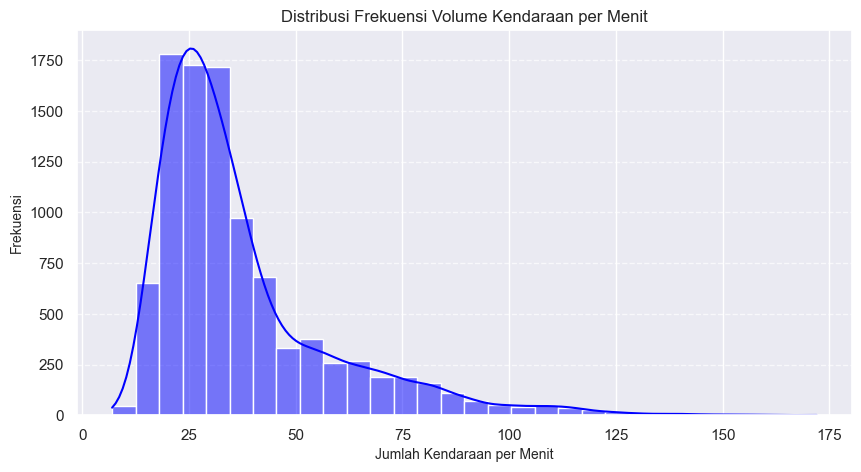

In [27]:
# DISTRIBUSI FREKUENSI VOLUME KENDARAAN #
# Melihat persebaran volume kendaraan per menit untuk mengetahui:
# - pola distribusi data
# - kemungkinan skewness
# - potensi outlier

plt.figure(figsize=(10, 5))
sns.histplot(merged_df['vehicle_count_1min'], kde=True, bins=30, color='blue')
plt.title('Distribusi Frekuensi Volume Kendaraan per Menit', fontsize=12)
plt.xlabel('Jumlah Kendaraan per Menit', fontsize=10)
plt.ylabel('Frekuensi', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

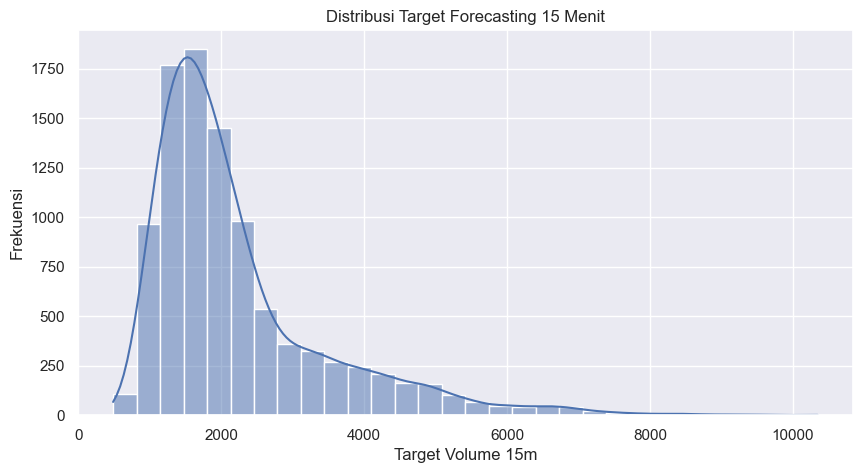

In [28]:
# DISTRIBUSI TARGET FORECASTING #
# - Memastikan target tidak flat/random
# - Melihat distribusi volume target
# - Mengecek potensi skewness/extreme outlier

plt.figure(figsize=(10,5))
sns.histplot(merged_df['target_volume_15m'], bins=30, kde=True)

plt.title('Distribusi Target Forecasting 15 Menit')
plt.xlabel('Target Volume 15m')
plt.ylabel('Frekuensi')

plt.show()


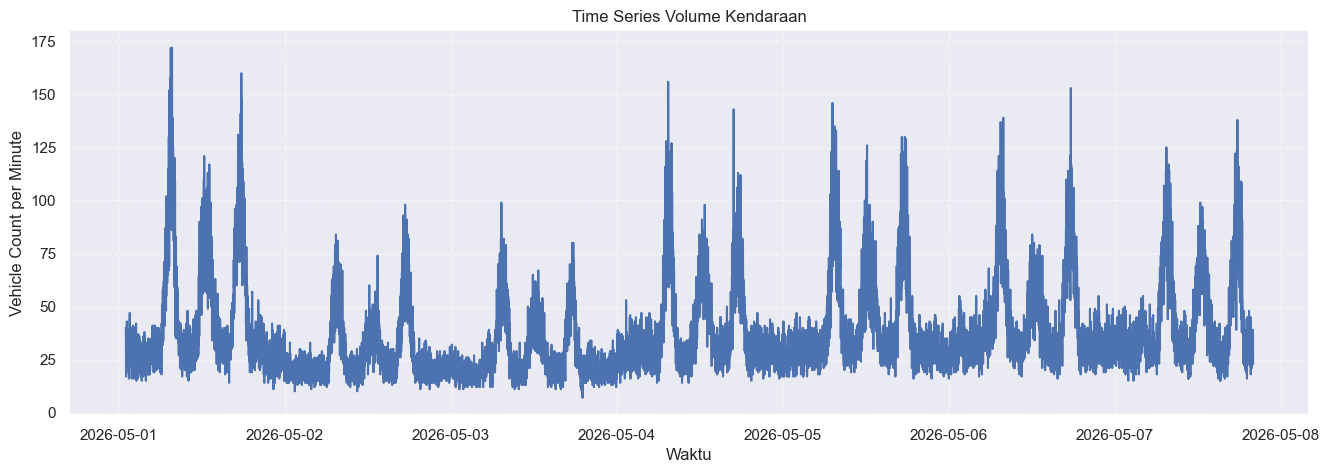

In [29]:
# TIME SERIES TRAFFIC VISUALIZATION #
# - Melihat pola perubahan traffic terhadap waktu
# - Mengidentifikasi rush hour
# - Mengecek seasonality traffic
# - Memastikan dataset tidak terlalu flat/random

plt.figure(figsize=(16,5))
plt.plot(merged_df['timestamp_wib'], merged_df['vehicle_count_1min'])

plt.title('Time Series Volume Kendaraan')
plt.xlabel('Waktu')
plt.ylabel('Vehicle Count per Minute')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

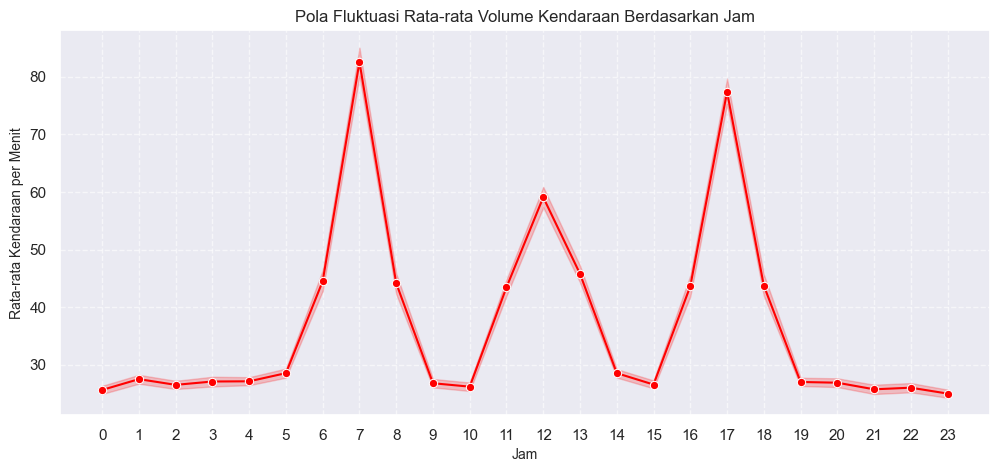

In [30]:
# POLA FLUKTUASI VOLUME BERDASARKAN JAM #
# Mengidentifikasi pola siklus harian lalu lintas seperti jam sibuk dan jam lengang

plt.figure(figsize=(12, 5))
sns.lineplot(data=merged_df, x='hour', y='vehicle_count_1min', estimator='mean', color='red', marker='o')
plt.title('Pola Fluktuasi Rata-rata Volume Kendaraan Berdasarkan Jam', fontsize=12)
plt.xlabel('Jam', fontsize=10)
plt.ylabel('Rata-rata Kendaraan per Menit', fontsize=10)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

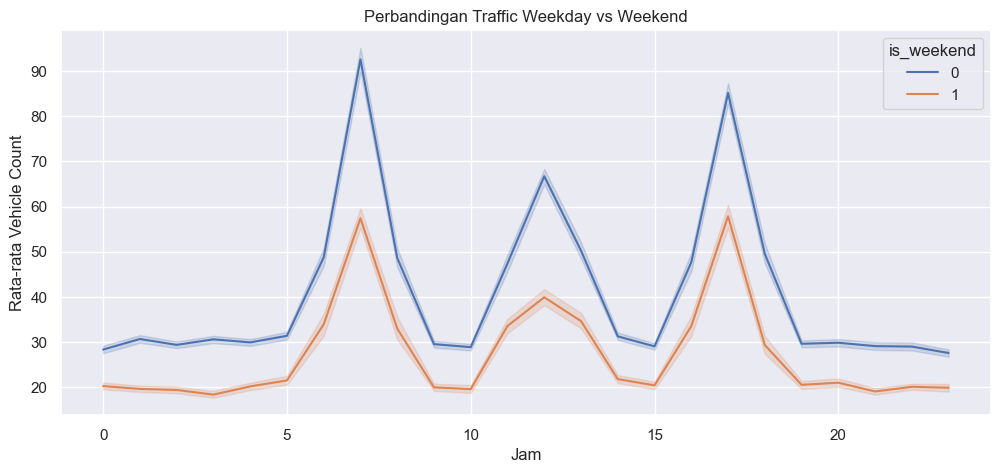

In [31]:
# WEEKDAY VS WEEKEND ANALYSIS #
plt.figure(figsize=(12,5))
sns.lineplot(data=merged_df, x='hour', y='vehicle_count_1min', hue='is_weekend', estimator='mean')

plt.title('Perbandingan Traffic Weekday vs Weekend')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Vehicle Count')

plt.show()

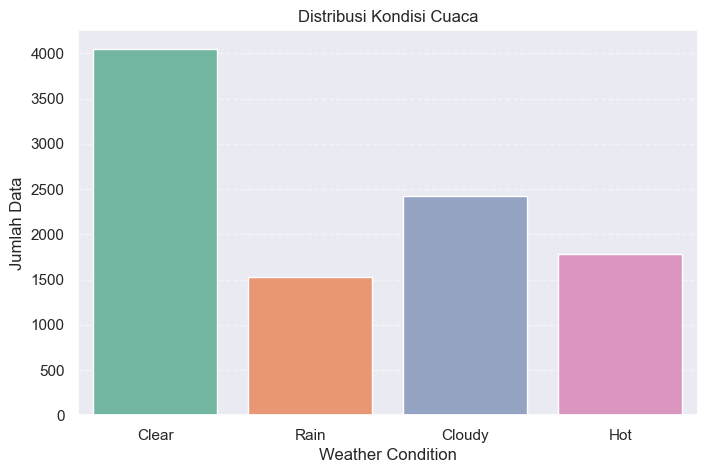


Persentase Distribusi Weather:
weather_condition
Clear     41.43
Cloudy    24.78
Hot       18.21
Rain      15.58
Name: proportion, dtype: float64


In [32]:
# DISTRIBUSI CUACA #
# Tujuan:
# - memastikan variasi cuaca realistis
# - memastikan model dapat belajar pengaruh weather
# - mengecek apakah data terlalu imbalance

# Reconstruct 'weather_condition' from one-hot encoded columns if it doesn't exist
if 'weather_condition' not in merged_df.columns:
    weather_cols_one_hot = [
        'weather_condition_Clear',
        'weather_condition_Cloudy',
        'weather_condition_Hot',
        'weather_condition_Rain'
    ]
    # Find the column that is 1 for each row
    merged_df['weather_condition'] = merged_df[weather_cols_one_hot].idxmax(axis=1).str.replace('weather_condition_', '')

plt.figure(figsize=(8, 5))
sns.countplot(
    data=merged_df,
    x='weather_condition',
    hue='weather_condition',
    palette='Set2',
    legend=False
)

plt.title('Distribusi Kondisi Cuaca')
plt.xlabel('Weather Condition')
plt.ylabel('Jumlah Data')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# tampilkan persentase distribusi
weather_dist = (
    merged_df['weather_condition']
    .value_counts(normalize=True) * 100
)

print("\nPersentase Distribusi Weather:")
print(weather_dist.round(2))

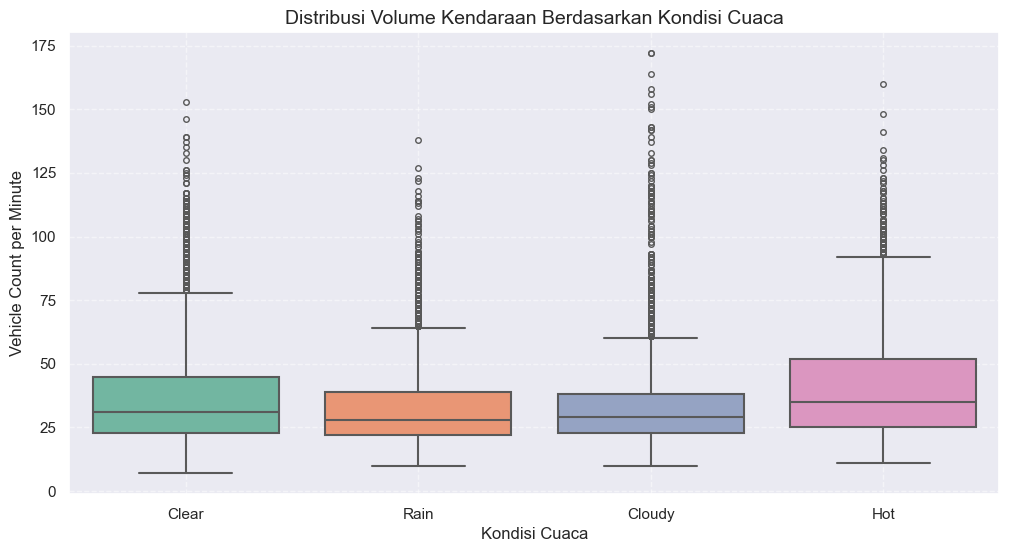

In [33]:
# DISTRIBUSI VOLUME BERDASARKAN KONDISI CUACA #
# Menganalisis pengaruh kondisi cuaca terhadap volume kendaraan dan aktivitas lalu lintas
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='weather_condition',
    y='vehicle_count_1min',
    data=merged_df,
    hue='weather_condition',
    legend=False,
    palette='Set2',
    linewidth=1.5,
    fliersize=4
)

plt.title('Distribusi Volume Kendaraan Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Vehicle Count per Minute')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

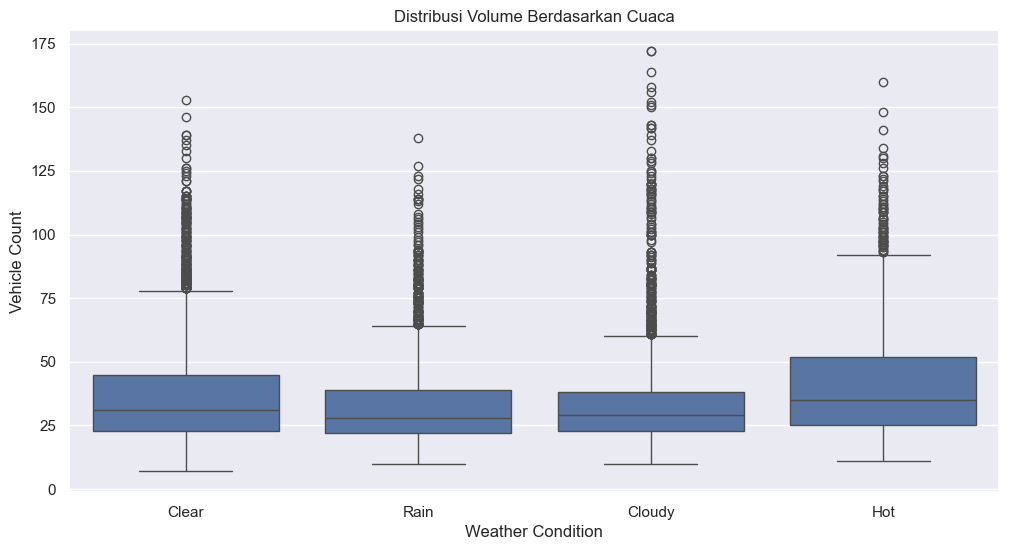

In [34]:
# ANALISIS VOLUME BERDASARKAN WEATHER #
plt.figure(figsize=(12,6))
sns.boxplot(data=merged_df, x='weather_condition', y='vehicle_count_1min')

plt.title('Distribusi Volume Berdasarkan Cuaca')
plt.xlabel('Weather Condition')
plt.ylabel('Vehicle Count')

plt.show()

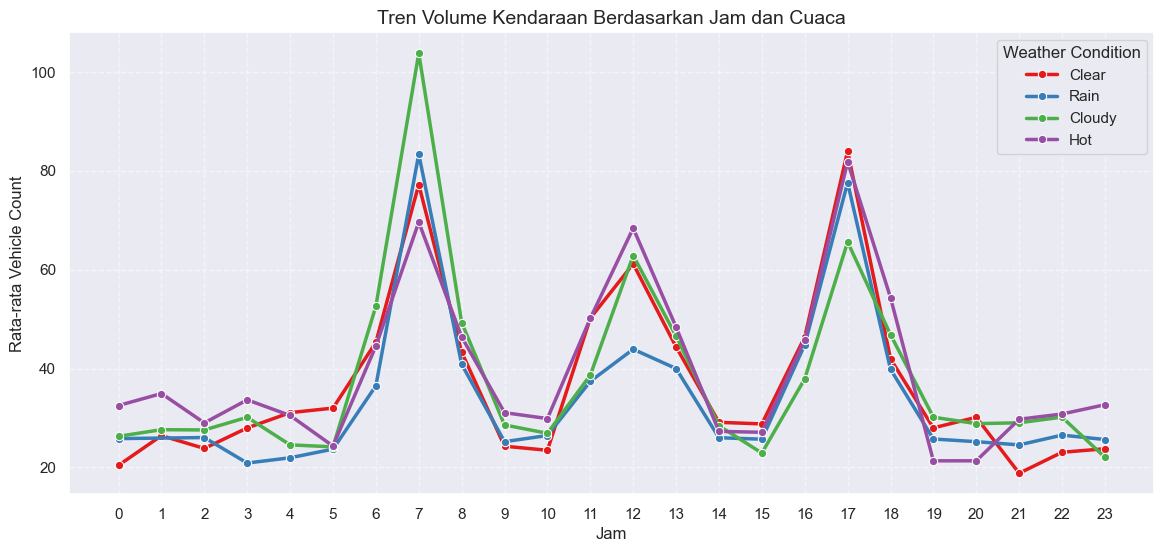

In [35]:
# TREN VOLUME BERDASARKAN JAM & CUACA #
# Melihat hubungan kombinasi antara waktu dan cuaca terhadap perubahan volume kendaraan
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=merged_df,
    x='hour',
    y='vehicle_count_1min',
    hue='weather_condition',
    estimator='mean',
    palette='Set1',
    marker='o',
    linewidth=2.5,
    errorbar=None  # Fokus pada garis tren rata-rata utama agar chart terlihat clean
)

plt.title('Tren Volume Kendaraan Berdasarkan Jam dan Cuaca', fontsize=14)
plt.xlabel('Jam')
plt.ylabel('Rata-rata Vehicle Count')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Weather Condition')
plt.show()

In [36]:
# EVENT / ACCIDENT / ROADWORK DISTRIBUTION #
# Memastikan simulator memiliki variasi realistis
print("\nDISTRIBUSI EVENT")
print(
    merged_df['event_flag']
    .value_counts()
)

print("\nDISTRIBUSI ROADWORK")
print(
    merged_df['roadwork_flag']
    .value_counts()
)

print("\nDISTRIBUSI ACCIDENT")
print(
    merged_df['accident_count']
    .value_counts()
)


DISTRIBUSI EVENT
event_flag
0    9415
1     365
Name: count, dtype: int64

DISTRIBUSI ROADWORK
roadwork_flag
0    9634
1     146
Name: count, dtype: int64

DISTRIBUSI ACCIDENT
accident_count
0    9489
1     291
Name: count, dtype: int64


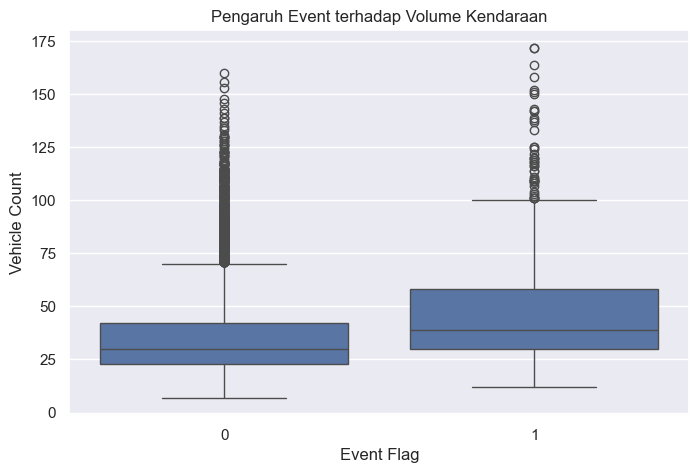

In [37]:
# EVENT IMPACT ANALYSIS #
plt.figure(figsize=(8,5))
sns.boxplot(data=merged_df, x='event_flag', y='vehicle_count_1min')

plt.title('Pengaruh Event terhadap Volume Kendaraan')
plt.xlabel('Event Flag')
plt.ylabel('Vehicle Count')

plt.show()

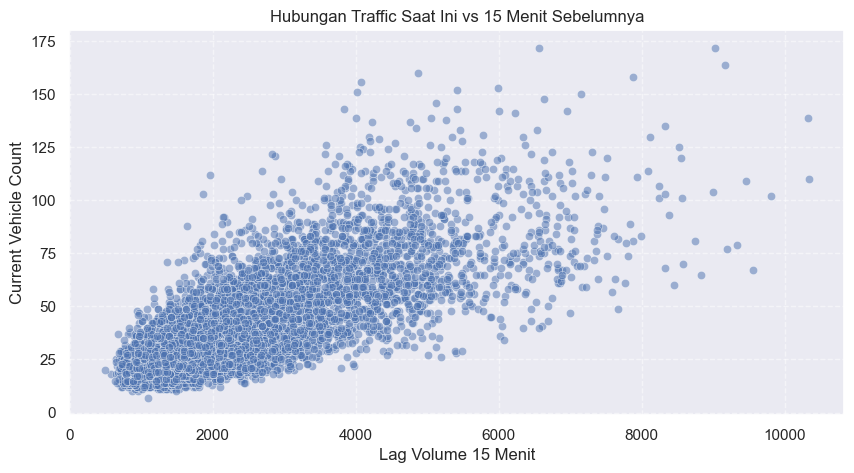

In [38]:
# VALIDASI LAG FEATURE #
# - Memastikan historical traffic berkorelasi dengan traffic saat ini
# - Membuktikan temporal dependency

plt.figure(figsize=(10,5))
sns.scatterplot(data=merged_df, x='lag_15', y='vehicle_count_1min', alpha=0.5)

plt.title('Hubungan Traffic Saat Ini vs 15 Menit Sebelumnya')
plt.xlabel('Lag Volume 15 Menit')
plt.ylabel('Current Vehicle Count')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

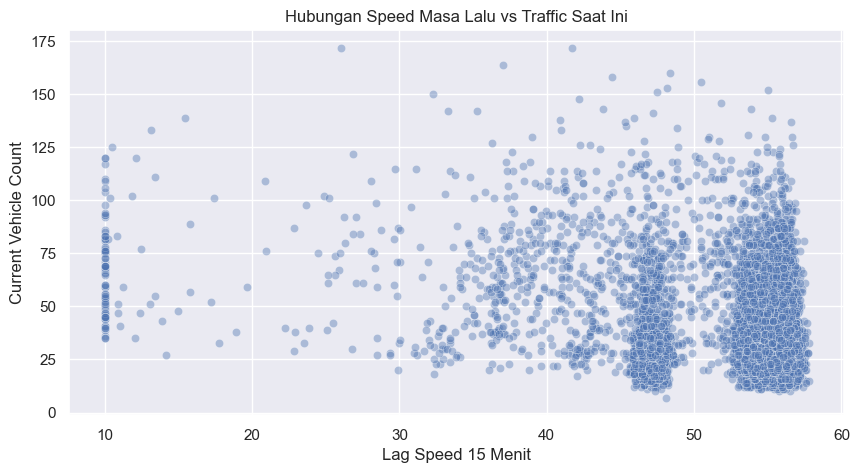

In [39]:
# ANALISIS LAG SPEED #
# Membuktikan speed mempengaruhi traffic future

plt.figure(figsize=(10,5))
sns.scatterplot(data=merged_df, x='lag_speed_15', y='vehicle_count_1min', alpha=0.4)

plt.title('Hubungan Speed Masa Lalu vs Traffic Saat Ini')
plt.xlabel('Lag Speed 15 Menit')
plt.ylabel('Current Vehicle Count')

plt.show()

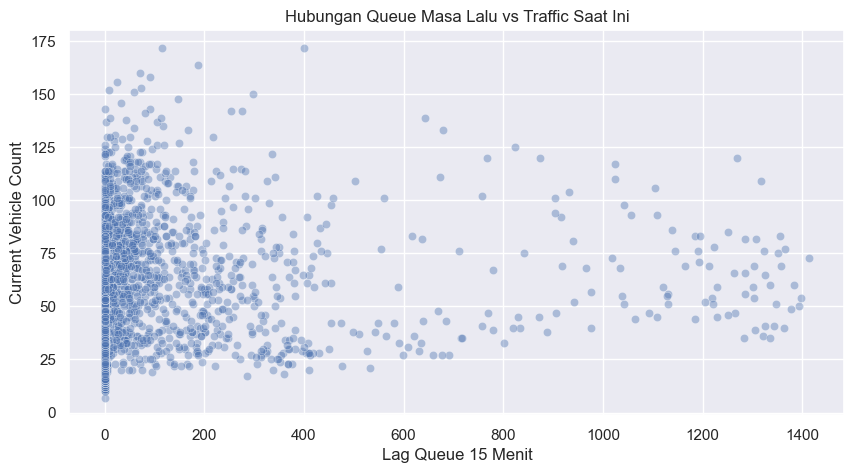

In [40]:
# ANALISIS LAG QUEUE #
# Membuktikan queue mempengaruhi traffic future

plt.figure(figsize=(10,5))
sns.scatterplot(data=merged_df, x='lag_queue_15', y='vehicle_count_1min', alpha=0.4)

plt.title('Hubungan Queue Masa Lalu vs Traffic Saat Ini')
plt.xlabel('Lag Queue 15 Menit')
plt.ylabel('Current Vehicle Count')

plt.show()

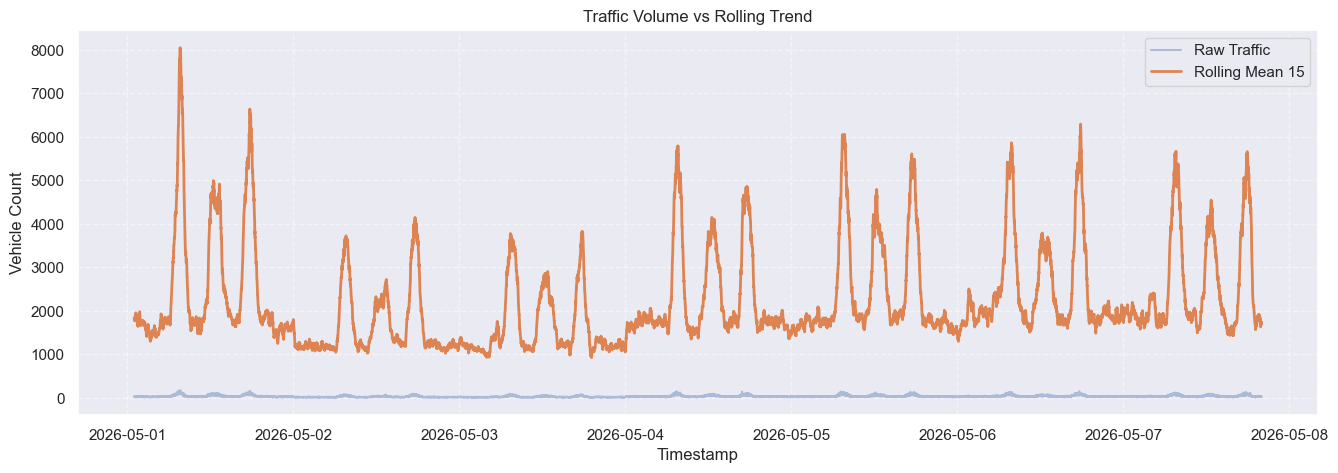

In [41]:
# ROLLING TREND ANALYSIS #
# - Membandingkan traffic asli vs trend smoothing
# - Melihat kestabilan traffic
# - Mengecek noise dan spike
#
# Rolling mean membantu melihat trend traffic jangka pendek.


plt.figure(figsize=(16,5))
plt.plot(merged_df['timestamp_wib'], merged_df['vehicle_count_1min'], alpha=0.4, label='Raw Traffic')

plt.plot(merged_df['timestamp_wib'], merged_df['roll_mean_15'], linewidth=2, label='Rolling Mean 15')

plt.title('Traffic Volume vs Rolling Trend')
plt.xlabel('Timestamp')
plt.ylabel('Vehicle Count')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

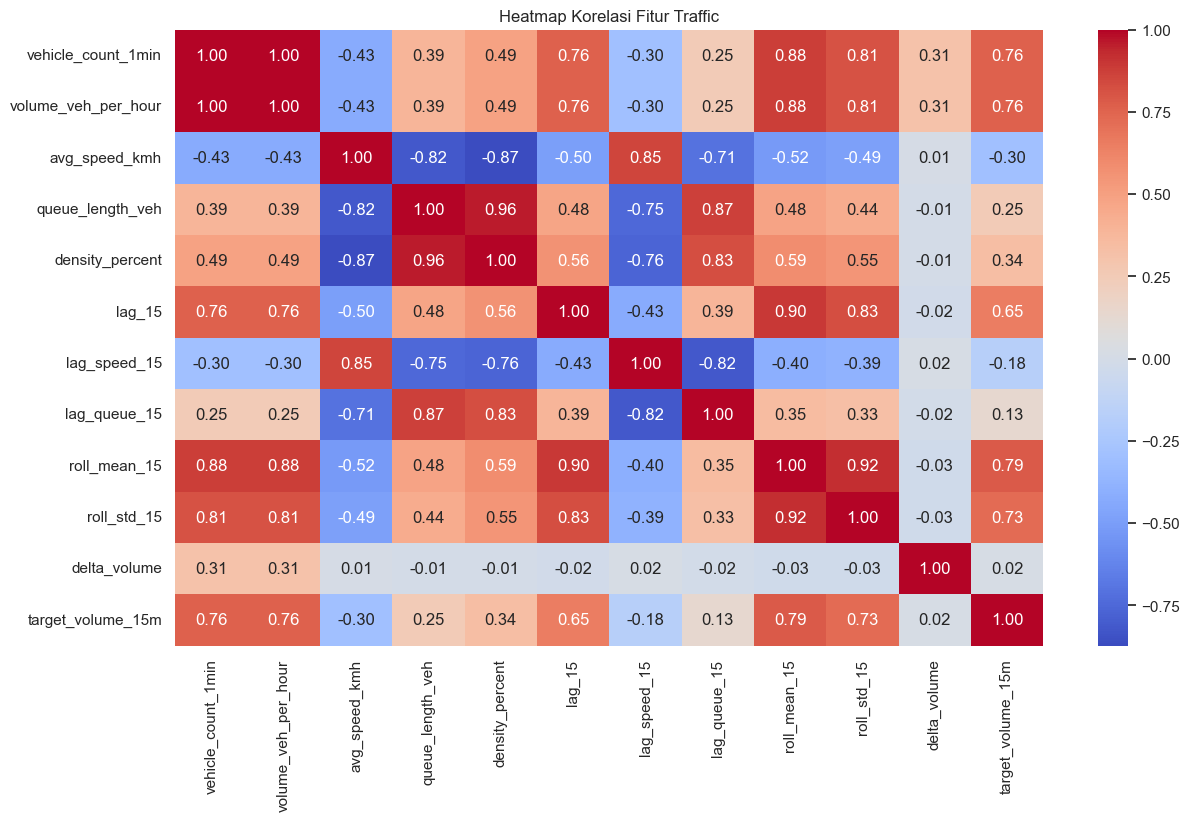

In [42]:
# HEATMAP KORELASI FITUR #
# - Melihat hubungan antar fitur numerik
# - Mengecek feature relevance
# - Mengecek multicollinearity

fitur_korelasi = [
    'vehicle_count_1min',
    'volume_veh_per_hour',
    'avg_speed_kmh',
    'queue_length_veh',
    'density_percent',
    'lag_15',
    'lag_speed_15',
    'lag_queue_15',
    'roll_mean_15',
    'roll_std_15',
    'delta_volume',
    'target_volume_15m'
]

plt.figure(figsize=(14,8))

sns.heatmap(
    merged_df[fitur_korelasi].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Fitur Traffic')
plt.show()

# **Save Data & File Markdown**

In [43]:
import json
import os
import numpy as np

# =========================================================
# SAVE FINAL CLEAN DATASET
# - sudah agregasi intersection
# - sudah feature engineering
# - sudah cleaning missing value
# - sudah lolos EDA validation
# - BELUM scaling
# =========================================================

merged_df.to_csv("traffix_lstm_ready.csv", index=False)
print("[SUCCESS] Dataset final berhasil disimpan.")


# =========================================================
# FEATURE COLUMNS UNTUK MODEL
# Kolom yang benar-benar dipakai model LSTM
# =========================================================

feature_columns = [
    # traffic volume
    # vehicle_count_1min opsional karena sangat berkorelasi
    # dengan volume_veh_per_hour
    "vehicle_count_1min",
    "volume_veh_per_hour",

    # traffic condition
    "avg_speed_kmh",
    "queue_length_veh",
    "wait_time_min",
    "green_seconds",
    "density_percent",

    # environment
    "weather_temp_c",

    # anomaly / incident
    "accident_count",
    "roadwork_flag",
    "event_flag",

    # time features
    "hour",
    "minute",
    "day",
    "day_of_week",
    "month",
    "is_holiday",
    "is_weekend",

    # cyclical encoding
    "hour_sin",
    "hour_cos",

    # temporal feature
    "delta_volume",

    # lag features
    "lag_1",
    "lag_5",
    "lag_15",
    "lag_30",
    "lag_60",

    # additional lag features
    "lag_speed_15",
    "lag_queue_15",

    # rolling statistics
    "roll_mean_15",
    "roll_std_15",
    "roll_min_15",
    "roll_max_15",
    "roll_median_15",

    "roll_mean_60",
    "roll_std_60",
    "roll_min_60",
    "roll_max_60",

    # weather one-hot encoding
    "weather_condition_Clear",
    "weather_condition_Cloudy",
    "weather_condition_Hot",
    "weather_condition_Rain",
]

with open("feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(
        feature_columns,
        f,
        indent=2,
        ensure_ascii=False
    )

print("[SUCCESS] feature_columns.json berhasil disimpan.")

print("\nJumlah feature model:")
print(len(feature_columns))


# =========================================================
# DATA DICTIONARY
# Dokumentasi arti tiap kolom dataset
# =========================================================

with open("data_dictionary.md", "w", encoding="utf-8") as f:
    f.write("# Data Dictionary — Traffix.id\n\n")
    column_descriptions = {
        # metadata
        "tick": "Urutan waktu simulasi per menit.",
        "timestamp_wib": "Timestamp simulasi zona WIB.",
        "intersectionId": "ID intersection traffic.",

        # traffic data
        "vehicle_count_1min": "Jumlah kendaraan per menit.",
        "volume_veh_per_hour": "Estimasi volume kendaraan per jam.",
        "avg_speed_kmh": "Kecepatan rata-rata kendaraan.",
        "queue_length_veh": "Jumlah antrean kendaraan.",
        "wait_time_min": "Total waktu tunggu kendaraan.",
        "green_seconds": "Durasi lampu hijau.",
        "density_percent": "Persentase kepadatan traffic.",

        # weather
        "weather_temp_c": "Temperatur lingkungan.",
        "weather_condition_Clear": "Indikator cuaca cerah.",
        "weather_condition_Cloudy": "Indikator cuaca berawan.",
        "weather_condition_Hot": "Indikator cuaca panas.",
        "weather_condition_Rain": "Indikator cuaca hujan.",

        # anomaly
        "accident_count": "Jumlah kecelakaan.",
        "roadwork_flag": "Indikator roadwork.",
        "event_flag": "Indikator event.",

        # time features
        "hour": "Jam.",
        "minute": "Menit.",
        "day": "Hari dalam bulan.",
        "day_of_week": "Hari dalam minggu.",
        "month": "Bulan.",
        "is_holiday": "Indikator hari libur.",
        "is_weekend": "Indikator weekend.",

        # cyclical encoding
        "hour_sin": "Encoding siklik jam (sin).",
        "hour_cos": "Encoding siklik jam (cos).",

        # dashboard categories
        "traffic_period": "Kategori periode traffic.",
        "congestion_level": "Kategori tingkat kemacetan.",

        # temporal features
        "delta_volume": "Perubahan volume traffic.",

        # lag features
        "lag_1": "Volume 1 menit sebelumnya.",
        "lag_5": "Volume 5 menit sebelumnya.",
        "lag_15": "Volume 15 menit sebelumnya.",
        "lag_30": "Volume 30 menit sebelumnya.",
        "lag_60": "Volume 60 menit sebelumnya.",

        # additional lag
        "lag_speed_15": "Kecepatan rata-rata 15 menit sebelumnya.",
        "lag_queue_15": "Queue length 15 menit sebelumnya.",

        # rolling features
        "roll_mean_15": "Rolling mean 15 menit.",
        "roll_std_15": "Rolling std 15 menit.",
        "roll_min_15": "Rolling minimum 15 menit.",
        "roll_max_15": "Rolling maksimum 15 menit.",
        "roll_median_15": "Rolling median 15 menit.",

        "roll_mean_60": "Rolling mean 60 menit.",
        "roll_std_60": "Rolling std 60 menit.",
        "roll_min_60": "Rolling minimum 60 menit.",
        "roll_max_60": "Rolling maksimum 60 menit.",

        # forecasting target
        "target_volume_15m": "Target forecasting 15 menit.",
        "target_volume_2h": "Target forecasting 2 jam.",
        "target_volume_4h": "Target forecasting 4 jam."
    }

    for col in merged_df.columns:
        desc = column_descriptions.get(col, "-")
        f.write(f"- `{col}` : {desc}\n")

print("[SUCCESS] data_dictionary.md berhasil disimpan.")


# =========================================================
# DATASET VALIDATION
# Menjelaskan bagaimana synthetic dataset dibuat
# =========================================================

with open("dataset_validation.md", "w", encoding="utf-8") as f:
    f.write("# Dataset Validation — Traffix.id\n\n")

    # Synthetic overview
    f.write("## Synthetic Dataset Overview\n")
    f.write(
        "Dataset synthetic dibuat untuk meniru pola traffic nyata "
        "menggunakan simulasi time-series intersection traffic.\n\n"
    )

    # Traffic variability
    f.write("## Traffic Variability\n")

    f.write("- Peak hour ditambahkan.\n")
    f.write("- Weekend pattern ditambahkan.\n")
    f.write("- Weather variability ditambahkan.\n")
    f.write("- Accident simulation ditambahkan.\n")
    f.write("- Roadwork simulation ditambahkan.\n")
    f.write("- Event simulation ditambahkan.\n\n")

    
    # Time-series integrity
    f.write("## Time-Series Integrity\n")

    f.write("- Data sudah diurutkan berdasarkan waktu.\n")
    f.write("- Tidak ada duplicate timestamp-intersection.\n")
    f.write("- Tidak ada missing value penting.\n")
    f.write("- Aggregation dilakukan menjadi 1 row per intersection per tick.\n\n")

    # Feature engineering
    f.write("## Feature Engineering\n")

    f.write("- Time features.\n")
    f.write("- Lag features.\n")
    f.write("- Rolling features.\n")
    f.write("- Delta traffic.\n")
    f.write("- Weather one-hot encoding.\n")
    f.write("- Multi-horizon forecasting target.\n")

print("[SUCCESS] dataset_validation.md berhasil disimpan.")


# =========================================================
# AGGREGATION RULES
# =========================================================

with open("aggregation_rules.md", "w", encoding="utf-8") as f:
    f.write("# Aggregation Rules — Traffix.id\n\n")

    f.write("- vehicle_count_1min : sum\n")
    f.write("- volume_veh_per_hour : sum\n")
    f.write("- avg_speed_kmh : mean\n")
    f.write("- queue_length_veh : sum\n")
    f.write("- wait_time_min : sum\n")
    f.write("- green_seconds : mean\n")
    f.write("- density_percent : mean\n")
    f.write("- weather_condition : mode_or_first\n")
    f.write("- weather_temp_c : mean\n")
    f.write("- accident_count : max\n")
    f.write("- roadwork_flag : max\n")
    f.write("- event_flag : max\n")

print("[SUCCESS] aggregation_rules.md berhasil disimpan.")


# =========================================================
# FINAL VALIDATION REPORT
# =========================================================

print("\n========== FINAL DATASET VALIDATION ==========")
print(f"\nShape dataset : {merged_df.shape}")

# Missing value check
print("\nJumlah missing value:")
print(merged_df.isnull().sum().sum())

# Duplicate validation
print("\nJumlah duplicate row:")
print(merged_df.duplicated().sum())

print("\nDuplicate timestamp-intersection:")
print(
    merged_df.duplicated(
        subset=["intersectionId", "timestamp_wib"]
    ).sum()
)

# All-zero row validation
print("\nJumlah all-zero row:")

all_zero_rows = (
    (
        merged_df[feature_columns]
        .select_dtypes(include=np.number)
        .sum(axis=1)
    ) == 0
).sum()

print(all_zero_rows)

# Weather distribution
print("\nDistribusi Weather (%):")

print(
    (
        merged_df["weather_condition"]
        .value_counts(normalize=True) * 100
    ).round(2)
)

# Accident/Event/Roadwork distribution
print("\nDistribusi Accident:")

print(
    merged_df["accident_count"]
    .value_counts()
)

print("\nDistribusi Event:")

print(
    merged_df["event_flag"]
    .value_counts()
)

print("\nDistribusi Roadwork:")

print(
    merged_df["roadwork_flag"]
    .value_counts()
)

# Forecasting target validation
print("\nStatistik Target Forecasting:")

print(
    merged_df["target_volume_15m"]
    .describe()
)

print("\nDistribusi Target Forecasting (Top 10):")

print(
    merged_df["target_volume_15m"]
    .value_counts()
    .head(10)
)

print("\n[SUCCESS] Semua file dokumentasi berhasil dibuat.")

[SUCCESS] Dataset final berhasil disimpan.
[SUCCESS] feature_columns.json berhasil disimpan.

Jumlah feature model:
41
[SUCCESS] data_dictionary.md berhasil disimpan.
[SUCCESS] dataset_validation.md berhasil disimpan.
[SUCCESS] aggregation_rules.md berhasil disimpan.

========== FINAL DATASET VALIDATION ==========

Shape dataset : (9780, 52)

Jumlah missing value:
0

Jumlah duplicate row:
0

Duplicate timestamp-intersection:
0

Jumlah all-zero row:
0

Distribusi Weather (%):
weather_condition
Clear     41.43
Cloudy    24.78
Hot       18.21
Rain      15.58
Name: proportion, dtype: float64

Distribusi Accident:
accident_count
0    9489
1     291
Name: count, dtype: int64

Distribusi Event:
event_flag
0    9415
1     365
Name: count, dtype: int64

Distribusi Roadwork:
roadwork_flag
0    9634
1     146
Name: count, dtype: int64

Statistik Target Forecasting:
count     9780.000000
mean      2234.713800
std       1266.659302
min        486.630000
25%       1405.585000
50%       1843.970000
7